In [97]:
# pip install numpy pandas matplotlib scikit-learn

In [98]:
# Importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve

from sklearn.svm import SVC

from sklearn.ensemble import ( RandomForestClassifier, GradientBoostingClassifier, VotingClassifier)

from sklearn.metrics import (accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,roc_curve,auc)

In [99]:
# Loading the dataset

data = load_breast_cancer()

# Features (inputs)

X = pd.DataFrame(data.data,columns=data.feature_names)

# Target/output

y = data.target
print("Dataset Shape:", X.shape)
print("\nFeature Names:")
print(X.columns)
print("\nFirst 5 rows:")
print(X.head())

Dataset Shape: (569, 30)

Feature Names:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0   

In [100]:
print(data.target_names)

['malignant' 'benign']


In [101]:
# Analyze the data

print(X.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [102]:
# Check Classes

pd.Series(y).value_counts()

1    357
0    212
Name: count, dtype: int64

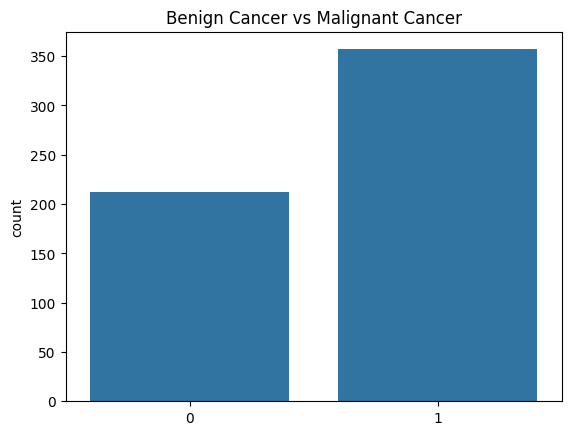

In [103]:
# Plotting

import seaborn as sns

sns.countplot(x=y)
plt.title("Benign Cancer vs Malignant Cancer")
plt.show()

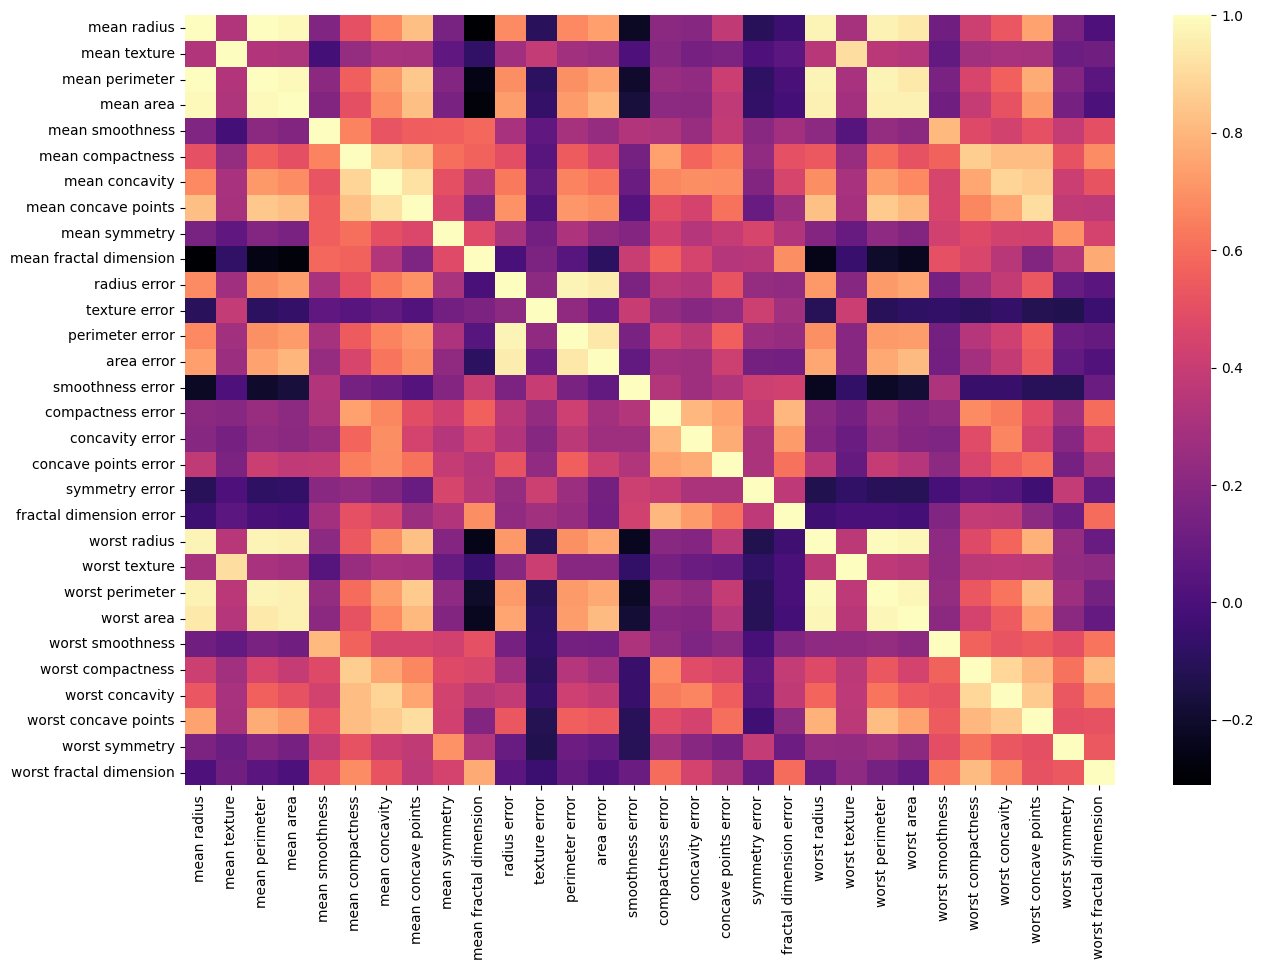

In [104]:
# Correlation Heatmap

plt.figure(figsize=(15,10))
sns.heatmap(X.corr(),cmap="magma")
plt.show()

In [105]:
# Preprocessing

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [106]:
# Run Model

rf=RandomForestClassifier()

svm=SVC(probability=True)

gb=GradientBoostingClassifier()

rf.fit(X_train,y_train)
svm.fit(X_train,y_train)
gb.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [107]:
# Individual Model Accuracy

models={
"Random Forest":rf,
"SVM":svm,
"Gradient Boosting":gb
}

for name,model in models.items():

    pred=model.predict(X_test)
    print(
        name,
        accuracy_score(y_test,pred)
    )

Random Forest 0.9649122807017544
SVM 0.9824561403508771
Gradient Boosting 0.956140350877193


In [108]:
# Ensemble Model

ensemble = VotingClassifier(estimators=[("rf",rf),("svm",svm),("gb",gb)],voting="soft")
ensemble.fit(X_train,y_train)
pred=ensemble.predict(X_test)
print("Ensemble Accuracy:",accuracy_score(y_test,pred))

Ensemble Accuracy: 0.9649122807017544


In [109]:
rf_accuracy=accuracy_score(y_test,rf.predict(X_test))

svm_accuracy=accuracy_score(y_test,svm.predict(X_test))

gb_accuracy=accuracy_score(y_test,gb.predict(X_test))

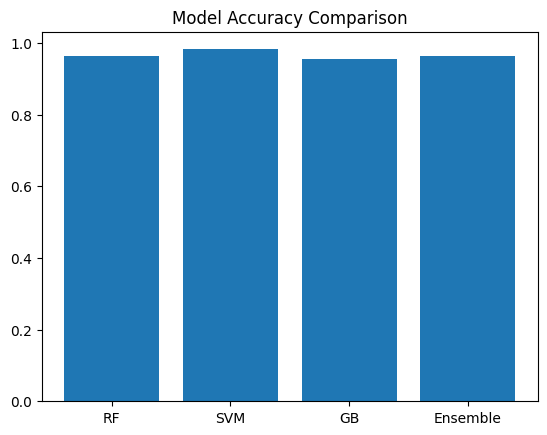

In [110]:
# Model Bar

models=["RF","SVM","GB","Ensemble"]

scores=[rf_accuracy,svm_accuracy,gb_accuracy,accuracy_score(y_test,pred)]
plt.bar(models,scores)

plt.title(
"Model Accuracy Comparison"
)

plt.show()

In [111]:
hard_model=VotingClassifier(
estimators=[
("rf",rf),
("svm",svm),
("gb",gb)
],
voting="hard"
)

hard_model.fit(
X_train,
y_train
)

hard_pred=hard_model.predict(
X_test
)

print(
"Hard Voting:",
accuracy_score(
y_test,
hard_pred
)
)

print(
"Soft Voting:",
accuracy_score(
y_test,
pred
)
)

Hard Voting: 0.956140350877193
Soft Voting: 0.9649122807017544


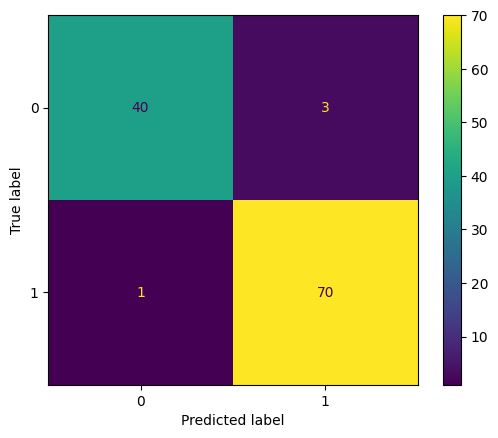

In [112]:
# Confusion Matrix

ConfusionMatrixDisplay.from_estimator(ensemble,X_test,y_test)
plt.show()

In [113]:
# Classification Report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [114]:
# Feature Importance

importance=rf.feature_importances_

features=X.columns
imp_df=pd.DataFrame({ "Feature":features,"Importance":importance})
imp_df=imp_df.sort_values(by="Importance",ascending=False).head(10)
print(imp_df)

                 Feature  Importance
23            worst area    0.133999
20          worst radius    0.111030
27  worst concave points    0.106606
7    mean concave points    0.104792
22       worst perimeter    0.101177
6         mean concavity    0.083166
2         mean perimeter    0.054975
26       worst concavity    0.040938
0            mean radius    0.035902
13            area error    0.033401


In [115]:
# Saving Results

imp_df.to_csv(
"important_features.csv",
index=False
)

print("Saved")

Saved


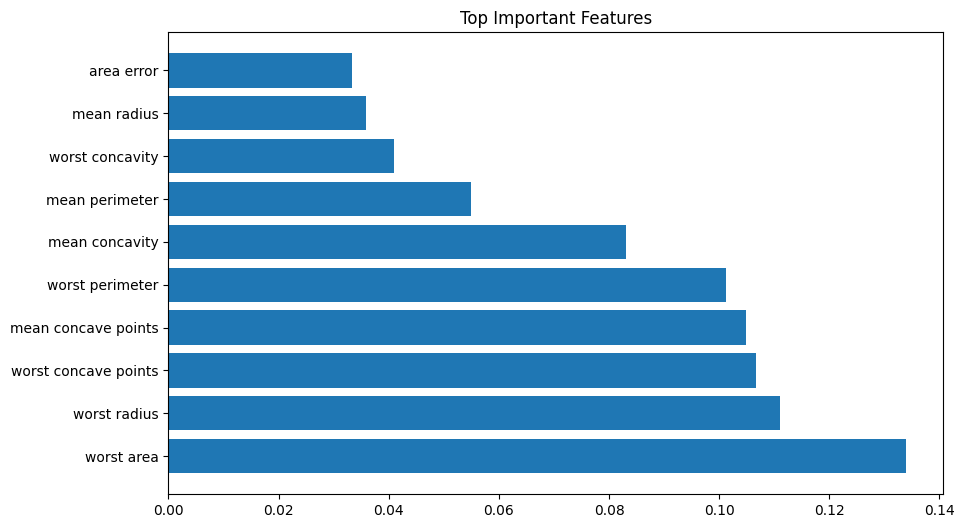

In [116]:
# Graphical Representation

plt.figure(figsize=(10,6))
plt.barh(imp_df["Feature"],imp_df["Importance"])
plt.title("Top Important Features")
plt.show()

In [117]:
# Hyperparameter Tuning

pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC())
])

params = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": ["scale", "auto"],
    "svc__kernel": ["rbf", "linear"]
}

grid = GridSearchCV(pipeline_svm, params, cv=5)
grid.fit(X, y)

print(grid.best_params_)

{'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}


In [118]:
# Cross Validation

from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ensemble)
])

scores = cross_val_score(pipeline, X, y, cv=5)

print("Mean Accuracy:",scores.mean())

Mean Accuracy: 0.971914299021891


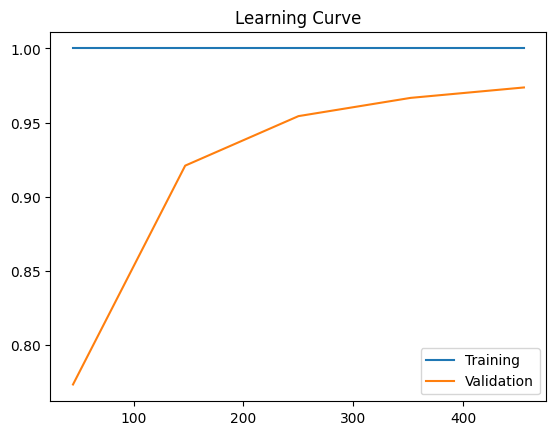

In [119]:
# Learning Curve

train_sizes,train_scores,test_scores=learning_curve(pipeline,X,y,cv=5)

plt.plot(train_sizes,train_scores.mean(axis=1),label="Training")

plt.plot(train_sizes,test_scores.mean(axis=1),label="Validation")

plt.legend()
plt.title("Learning Curve")

plt.show()

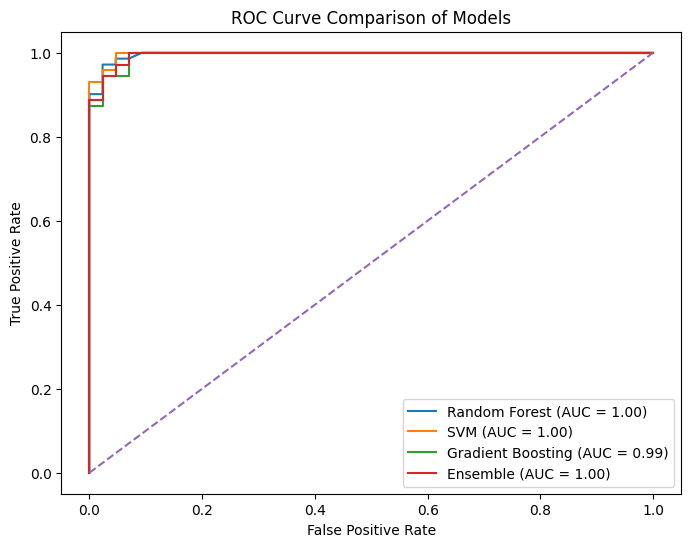

In [120]:
# ROC(Receiver Operating Characteristic curve)

rf_probs = rf.predict_proba(X_test)[:,1]
svm_probs = svm.predict_proba(X_test)[:,1]
gb_probs = gb.predict_proba(X_test)[:,1]
ensemble_probs = ensemble.predict_proba(X_test)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)
ens_fpr, ens_tpr, _ = roc_curve(y_test, ensemble_probs)

rf_auc = auc(rf_fpr, rf_tpr)
svm_auc = auc(svm_fpr, svm_tpr)
gb_auc = auc(gb_fpr, gb_tpr)
ens_auc = auc(ens_fpr, ens_tpr)

plt.figure(figsize=(8,6))

plt.plot(rf_fpr, rf_tpr, label="Random Forest (AUC = %.2f)" % rf_auc)
plt.plot(svm_fpr, svm_tpr, label="SVM (AUC = %.2f)" % svm_auc)
plt.plot(gb_fpr, gb_tpr, label="Gradient Boosting (AUC = %.2f)" % gb_auc)
plt.plot(ens_fpr, ens_tpr, label="Ensemble (AUC = %.2f)" % ens_auc)

# Diagonal line (random model)
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Models")
plt.legend()
plt.show()

In [121]:
import pickle

pickle.dump(ensemble,open("cancer_model.pkl","wb"))

print("Model Saved")

Model Saved


In [122]:
pickle.dump(
scaler,open("scaler.pkl","wb"))
print("Scaler Saved")

Scaler Saved


In [123]:
model=pickle.load(
open("cancer_model.pkl","rb"))

In [124]:
sample = X.iloc[[50]]

sample_scaled = scaler.transform(sample)

prediction = model.predict(sample_scaled)

if prediction[0]==1:
    print("Benign")
else:
    print("Malignant")

Benign


In [125]:
import random

test_cases=random.sample(range(569),10)
for i in test_cases:

    print( i, "-", data.target_names[y[i]] )

290 - benign
299 - benign
535 - malignant
397 - benign
176 - benign
114 - benign
382 - benign
270 - benign
369 - malignant
391 - benign
